# DelFalco's Yelp Reviews Analysis (NLP)


In [1]:
import pandas as pd
# Load in the data from JSON file
data = pd.read_json('restaurant.json')
data.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
109,lDJIaF4eYRF4F7g6Zb9euw,lb0QUR5bc4O-Am4hNq9ZGg,r5PLDU-4mSbde5XekTXSCA,4,2,0,0,I used to work food service and my manager at ...,2013-01-27 17:54:54
1013,vvIzf3pr8lTqE_AOsxmgaA,MAmijW4ooUzujkufYYLMeQ,r5PLDU-4mSbde5XekTXSCA,4,0,0,0,We have been trying Eggplant sandwiches all ov...,2015-04-15 04:50:56
1204,UF-JqzMczZ8vvp_4tPK3bQ,slfi6gf_qEYTXy90Sw93sg,r5PLDU-4mSbde5XekTXSCA,5,1,0,0,Amazing Steak and Cheese... Better than any Ph...,2011-03-20 00:57:45
1251,geUJGrKhXynxDC2uvERsLw,N_-UepOzAsuDQwOUtfRFGw,r5PLDU-4mSbde5XekTXSCA,1,0,0,0,Although I have been going to DeFalco's for ye...,2018-07-17 01:48:23
1354,aPctXPeZW3kDq36TRm-CqA,139hD7gkZVzSvSzDPwhNNw,r5PLDU-4mSbde5XekTXSCA,2,0,0,0,"Highs: Ambience, value, pizza and deserts. Thi...",2018-01-21 10:52:58


In [2]:
menu = ["Cheese Steak", "Cheesesteak", "Steak and Cheese", "Italian Combo", "Tiramisu", "Cannoli",
        "Chicken Salad", "Chicken Spinach Salad", "Meatball", "Pizza", "Pizzas", "Spaghetti",
        "Bruchetta", "Eggplant", "Italian Beef", "Purista", "Pasta", "Calzones",  "Calzone",
        "Italian Sausage", "Chicken Cutlet", "Chicken Parm", "Chicken Parmesan", "Gnocchi",
        "Chicken Pesto", "Turkey Sandwich", "Turkey Breast", "Ziti", "Portobello", "Reuben",
        "Mozzarella Caprese",  "Corned Beef", "Garlic Bread", "Pastrami", "Roast Beef",
        "Tuna Salad", "Lasagna", "Artichoke Salad", "Fettuccini Alfredo", "Chicken Parmigiana",
        "Grilled Veggie", "Grilled Veggies", "Grilled Vegetable", "Mac and Cheese", "Macaroni",  
         "Prosciutto", "Salami"]

## 1. Data Cleaning and Preprocessing 

**Text Cleaning: The following operations were performed on the review texts:**

Converting the text to lowercase 

Removing punctuation marks and special characters

Removing stop words

Tokenizing the words

Reducing words to their root forms using lemmatization or stemming


In [5]:
df2 = data.copy()

In [6]:
import re
import nltk
from nltk.tokenize import word_tokenize

In [7]:
nltk.download('punkt')

def part1_preprocess(text):
    # If its empty convert to string
    text = str(text)
    
    # Converting to lowercase
    text = text.lower()
    
    # (don't -> dont)
    text = text.replace("'", "")
    
    # Removing punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenizing the words
    tokens = word_tokenize(text)
    
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sevva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [8]:
df2['tokenized_text'] = df2['text'].apply(part1_preprocess)
df2[['text', 'tokenized_text']].head()

,text,tokenized_text
109,I used to work food service and my manager at ...,"[i, used, to, work, food, service, and, my, ma..."
1013,We have been trying Eggplant sandwiches all ov...,"[we, have, been, trying, eggplant, sandwiches,..."
1204,Amazing Steak and Cheese... Better than any Ph...,"[amazing, steak, and, cheese, better, than, an..."
1251,Although I have been going to DeFalco's for ye...,"[although, i, have, been, going, to, defalcos,..."
1354,"Highs: Ambience, value, pizza and deserts. Thi...","[highs, ambience, value, pizza, and, deserts, ..."


In [9]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [10]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

# removing neg words
words_to_keep = {"not", "no", "cant", "dont", "never"}
stop_words = stop_words - words_to_keep

# Reducing words to root forms
lemmatizer = WordNetLemmatizer()

def part2_preprocess(tokens):
    # 1. Stop words cleaning
    meaningful_tokens = [word for word in tokens if word not in stop_words]
    
    # 2. Lemmatization
    final_tokens = [lemmatizer.lemmatize(word) for word in meaningful_tokens]
    
    # to connect
    return " ".join(final_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sevva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sevva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
df2['clean_text'] = df2['tokenized_text'].apply(part2_preprocess)
df2[['text', 'clean_text']].head()

,text,clean_text
109,I used to work food service and my manager at ...,used work food service manager time recommende...
1013,We have been trying Eggplant sandwiches all ov...,trying eggplant sandwich valley day love eggpl...
1204,Amazing Steak and Cheese... Better than any Ph...,amazing steak cheese better philly one ever ta...
1251,Although I have been going to DeFalco's for ye...,although going defalcos year last visit waste ...
1354,"Highs: Ambience, value, pizza and deserts. Thi...",high ambience value pizza desert genuine itali...


# 2. Data Analysis

**Sentiment Analysis:** Sentiment analysis can be performed to determine whether Yelp reviews are positive, negative, or neutral. The `stars` column can be used for this purpose.

**Extracting Dish Names:** You can extract dish names from the reviews to identify which dishes customers are commenting on.

**Calculating Dish Ratings:** By matching the comments about specific dishes with the sentiment analysis results, you can determine which dishes received positive or negative feedback.


In [13]:
def assign_sentiment(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

df2['sentiment'] = df2['stars'].apply(assign_sentiment)
print("Sentiment Analysis:")
print(df2['sentiment'].value_counts())

Sentiment Analysis:
sentiment
Positive    1107
Negative     113
Neutral      101
Name: count, dtype: int64


C:\Users\sevva\AppData\Local\Temp\ipykernel_2108\3162439248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x='sentiment', palette='viridis')


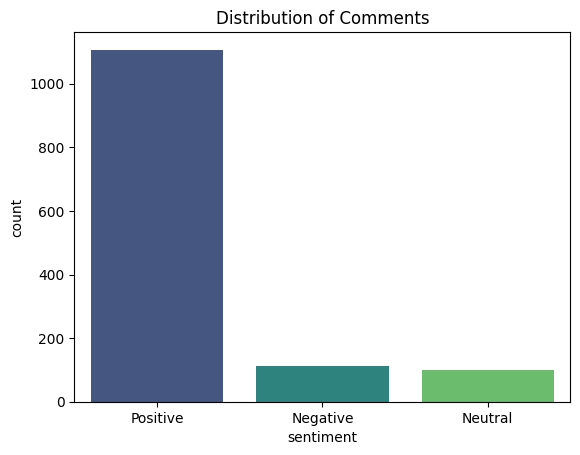

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df2, x='sentiment', palette='viridis')
plt.title('Distribution of Comments')
plt.show()

In [21]:
menu_dishes_lower = [dish.lower() for dish in menu]

def extract_dishes(clean_text):
    clean_text_lower = str(clean_text).lower()
    dishes_found = []
    
    for dish in menu_dishes_lower:
        if dish in clean_text_lower:
            dishes_found.append(dish)
            
    return list(set(dishes_found))

In [22]:
df2['mentioned_dishes'] = df2['clean_text'].apply(extract_dishes)
df2[df2['mentioned_dishes'].map(len) > 0][['text', 'mentioned_dishes', 'sentiment']].head()

,text,mentioned_dishes,sentiment
109,I used to work food service and my manager at ...,"[chicken parmigiana, chicken parm]",Positive
1013,We have been trying Eggplant sandwiches all ov...,"[eggplant, pasta]",Positive
1204,Amazing Steak and Cheese... Better than any Ph...,[pizza],Positive
1251,Although I have been going to DeFalco's for ye...,[meatball],Negative
1354,"Highs: Ambience, value, pizza and deserts. Thi...","[pizza, cannoli, pasta]",Negative


In [23]:
df_exploded = df2.explode('mentioned_dishes')

In [24]:
# exclude rows that don't contain food names from the filter.
df_exploded = df_exploded.dropna(subset=['mentioned_dishes'])

In [25]:
# crosstab to find out how many positive/negative reviews each dish received.
dish_report = pd.crosstab(df_exploded['mentioned_dishes'], df_exploded['sentiment'])

In [26]:
# To ensure the table doesn't have any missing columns, let's make the columns safe if necessary.
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in dish_report.columns:
        dish_report[col] = 0

In [27]:
# number of total comment
dish_report['Total_Reviews'] = dish_report['Negative'] + dish_report['Neutral'] + dish_report['Positive']

In [28]:
# percantage of neg comments
dish_report['Negative_Percentage (%)'] = (dish_report['Negative'] / dish_report['Total_Reviews']) * 100

In [29]:
final_report = dish_report[dish_report['Total_Reviews'] >= 2].sort_values(by='Negative_Percentage (%)', ascending=False)
final_report

sentiment,Negative,Neutral,Positive,Total_Reviews,Negative_Percentage (%)
mentioned_dishes,,,,,
chicken cutlet,3,2,6,11,27.272727
tuna salad,1,0,4,5,20.000000
spaghetti,7,4,25,36,19.444444
turkey sandwich,1,0,5,6,16.666667
italian combo,3,2,17,22,13.636364
italian beef,3,5,17,25,12.000000
pastrami,1,0,8,9,11.111111
salami,3,0,26,29,10.344828
garlic bread,4,4,31,39,10.256410


# 3. Analyzing the Popularity and Customer Satisfaction of Dishes

**Frequency Analysis:** Frequency analysis can be performed to identify the dishes that are mentioned most often in Yelp reviews.

**Sentiment Scores:** An average sentiment score can be calculated for each dish, for example, using a scale from 1 to 5.

**Evaluating the Dishes:** A comparison can be made between the negative and positive comments for each dish to understand which dishes are liked and which ones receive more criticism.

In [41]:
dish_frequencies = df_exploded['mentioned_dishes'].value_counts().reset_index()
dish_frequencies.columns = ['Dish_Name', 'Mention_Frequency']
dish_frequencies.head(10)

,Dish_Name,Mention_Frequency
0,pizza,287
1,pasta,269
2,meatball,157
3,cheesesteak,107
4,calzone,98
5,cannoli,94
6,chicken parm,88
7,cheese steak,84
8,eggplant,69
9,purista,63


In [42]:
dish_avg_stars = df_exploded.groupby('mentioned_dishes')['stars'].mean().reset_index()
dish_avg_stars.columns = ['Dish_Name', 'Average_Stars_Rating']
dish_avg_stars.sort_values(by='Average_Stars_Rating', ascending=True).head(10)

,Dish_Name,Average_Stars_Rating
6,chicken cutlet,3.545455
35,spaghetti,3.888889
19,italian beef,3.920000
23,macaroni,4.000000
37,tuna salad,4.000000
39,turkey sandwich,4.000000
28,pizzas,4.000000
20,italian combo,4.045455
16,garlic bread,4.128205
33,roast beef,4.142857


In [33]:
# Evaluating the Dishes
dish_evaluation = pd.crosstab(df_exploded['mentioned_dishes'], df_exploded['sentiment']).reset_index()

# column names
dish_evaluation.columns = ['Dish_Name', 'Negative_Comments', 'Neutral_Comments', 'Positive_Comments']

# average stars
dish_evaluation = pd.merge(dish_evaluation, dish_avg_stars, on='Dish_Name')

# frequency
dish_evaluation = pd.merge(dish_evaluation, dish_frequencies, on='Dish_Name')

# neg comments
dish_evaluation['Criticism_Rate (%)'] = (dish_evaluation['Negative_Comments'] / dish_evaluation['Mention_Frequency']) * 100

final_menu_analysis = dish_evaluation[dish_evaluation['Mention_Frequency'] >= 2].sort_values(by='Average_Stars_Rating', ascending=True)
final_menu_analysis

,Dish_Name,Negative_Comments,Neutral_Comments,Positive_Comments,Average_Stars_Rating,Mention_Frequency,Criticism_Rate (%)
6,chicken cutlet,3,2,6,3.545455,11,27.272727
35,spaghetti,7,4,25,3.888889,36,19.444444
19,italian beef,3,5,17,3.920000,25,12.000000
23,macaroni,0,2,3,4.000000,5,0.000000
37,tuna salad,1,0,4,4.000000,5,20.000000
39,turkey sandwich,1,0,5,4.000000,6,16.666667
20,italian combo,3,2,17,4.045455,22,13.636364
16,garlic bread,4,4,31,4.128205,39,10.256410
33,roast beef,0,2,5,4.142857,7,0.000000
14,eggplant,7,8,54,4.159420,69,10.144928


# 4. Visualizing the Results

**Word Cloud:** You can visualize the most frequently mentioned dish names and words.

**Bar Chart:** You can create a chart showing which dishes received the most negative reviews.

**Pie Chart:** You can visualize the sentiment distribution of the reviews, such as positive, negative, and neutral.


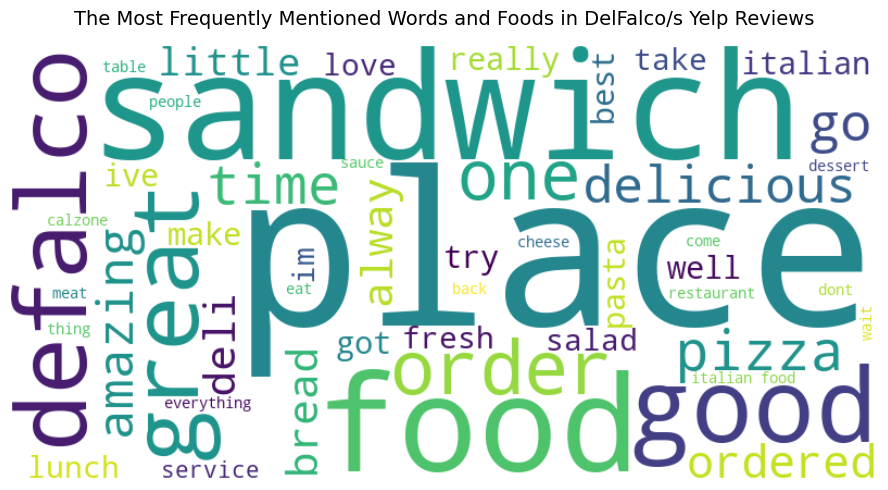

In [36]:
from wordcloud import WordCloud

all_reviews_text = " ".join(df2['clean_text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(all_reviews_text)
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off') 

plt.title('The Most Frequently Mentioned Words and Foods in DelFalco/s Yelp Reviews', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('delfalcos_wordcloud.png', dpi=300)

C:\Users\sevva\AppData\Local\Temp\ipykernel_2108\995555315.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


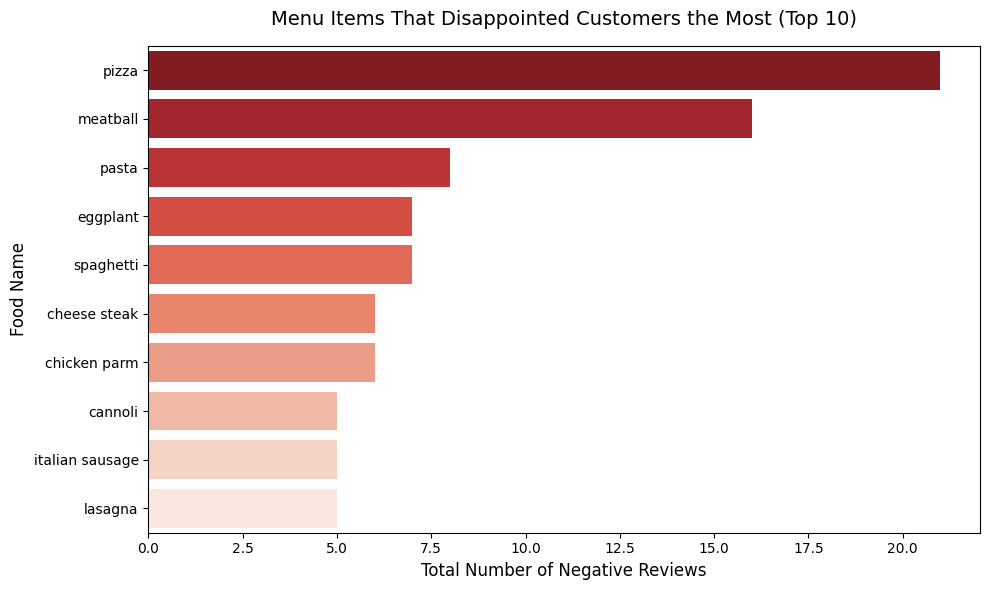

In [37]:
top_negative_dishes = final_menu_analysis.sort_values(by='Negative_Comments', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_negative_dishes, 
    x='Negative_Comments', 
    y='Dish_Name', 
    palette='Reds_r',
    ax=ax
)

ax.set_title('Menu Items That Disappointed Customers the Most (Top 10)', fontsize=14, pad=15)
ax.set_xlabel('Total Number of Negative Reviews', fontsize=12)
ax.set_ylabel('Food Name', fontsize=12)

plt.tight_layout()
plt.savefig('disappointment_bar_chart.png', dpi=300)

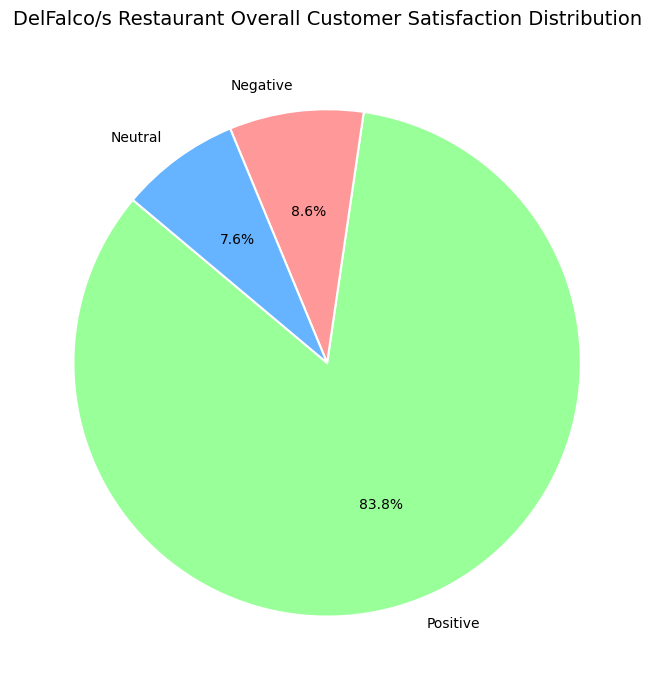

In [38]:
sentiment_counts = df2['sentiment'].value_counts()

labels = sentiment_counts.index
sizes = sentiment_counts.values

color_map = {'Positive': '#99ff99', 'Negative': '#ff9999', 'Neutral': '#66b3ff'}
colors = [color_map[label] for label in labels]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',
    startangle=140,    
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax.set_title('DelFalco/s Restaurant Overall Customer Satisfaction Distribution', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('restaurant_general_pie_chart.png', dpi=300)

## Which menu item received the worst reviews?

In [39]:
worst_dishes = final_menu_analysis[final_menu_analysis['Mention_Frequency'] >= 3].sort_values(by='Average_Stars_Rating', ascending=True)
worst_dishes[['Dish_Name', 'Average_Stars_Rating', 'Criticism_Rate (%)', 'Negative_Comments']].head()

,Dish_Name,Average_Stars_Rating,Criticism_Rate (%),Negative_Comments
6,chicken cutlet,3.545455,27.272727,3
35,spaghetti,3.888889,19.444444,7
19,italian beef,3.920000,12.000000,3
23,macaroni,4.000000,0.000000,0
37,tuna salad,4.000000,20.000000,1


## Which menu items received the most reviews?

In [40]:
most_reviewed_dishes = final_menu_analysis.sort_values(by='Mention_Frequency', ascending=False)
most_reviewed_dishes[['Dish_Name', 'Mention_Frequency', 'Positive_Comments', 'Negative_Comments', 'Average_Stars_Rating']].head()

,Dish_Name,Mention_Frequency,Positive_Comments,Negative_Comments,Average_Stars_Rating
27,pizza,287,243,21,4.344948
25,pasta,269,241,8,4.457249
24,meatball,157,123,16,4.178344
5,cheesesteak,107,93,4,4.448598
1,calzone,98,88,4,4.479592
